In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xobjects as xo
import xtrack as xt
import re

In [3]:
line_path = "../acc-models-fcc-ee/lattices/t/fccee_t_merged_dipoles.json"

## Ideal Xsuite tapering

In [4]:
line = xt.load(line_path).fccee_p_ring
line.build_tracker(_context=xo.ContextCpu())
line.configure_radiation(model='mean')

Loading line from dict: 100%|██████████| 18995/18995 [00:03<00:00, 5875.83it/s]


In [5]:
line.compensate_radiation_energy_loss(delta0='zero_mean')

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 187_227_640.077 eV             
Energy loss: 30_859_907.299 eV             
Energy loss: -8_193_207.838 eV             
Energy loss: -3_540_866.802 eV             
Energy loss: -2_868.191 eV             
Energy loss: 250_680.922 eV             
Energy loss: 41_550.544 eV             
Energy loss: -10_927.730 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag


In [6]:
elements_with_taper = np.asarray([ name for name in line.element_names if hasattr(line[name], "delta_taper")], dtype=str)
ideal_delta_taper = np.asarray([float(line[name].delta_taper) for name in elements_with_taper], dtype=float).copy()
ideal_taper_by_name = dict(zip(elements_with_taper, ideal_delta_taper))
twiss_ideal = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
tt  = line.get_table()
print(f'Taperable elements: {len(ideal_delta_taper)}')
print(f'Ideal emittance: x={float(twiss_ideal.eq_gemitt_x)*1e9:.4g} nm, y={float(twiss_ideal.eq_gemitt_y)*1e12:.4g} pm')

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Taperable elements: 15985
Ideal emittance: x=2.189 nm, y=0.06379 pm


In [7]:
def clear_delta_taper(line, elements_with_taper ):
    for name in elements_with_taper:
        line[name].delta_taper = 0.0

def restore_ideal_tapering(line,elements_with_taper, ideal_delta_taper):
    for name, value in zip(elements_with_taper, ideal_delta_taper):
        line[name].delta_taper = float(value)


def read_rf_phase(line):
    rows = []

    for name in line.element_names:
        element = line[name]

        if not hasattr(element, "voltage"):
            continue

        voltage = float(element.voltage)

        if voltage == 0:
            continue

        phase_taper = float(
            getattr(element, "phase_taper", 0.0)
        )

        rows.append({
            "name": name,
            "voltage_MV": voltage * 1e-6,
            "phase_taper_rad": phase_taper,
            "phase_taper_deg": np.rad2deg(phase_taper),
        })

    return pd.DataFrame(rows)

In [8]:
rf_phase_ideal = read_rf_phase(line)
rf_phase_ideal 

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [9]:
# i take this function from https://github.com/xsuite/xtrack/blob/main/xtrack/tapering.py

import numpy as np
from scipy.constants import c as clight

import xtrack as xt
import xobjects as xo

_print = print  # >>> CHANGED: replacement for `from .general import _print` in a notebook


def get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12,
                                      max_iter=100, verbose=True,
                                      co_search_at=None,
                                      **kwargs):

    assert isinstance(line._context, xo.ContextCpu), "Only CPU context is supported"
    assert line.particle_ref is not None, "Particle reference is not set"
    assert np.abs(line.particle_ref.q0) == 1, "Only |q0| = 1 is supported (for now)"

    enames_no_autodrift = [nn for nn in line.element_names if not nn.startswith('||drift_')]
    if len(set(enames_no_autodrift)) != len(enames_no_autodrift):
        raise ValueError("Line must not contain repeated elements to use "
                         "`solve_energy_profile_and_rf_phase(...)`. ")

    ele_type = line.tracker._tracker_data_base._line_table.element_type
    ele_type_set = set(ele_type)
    for et in ele_type_set:
        if 'SliceCavity' in et:
            raise ValueError(
                f"Element type '{et}' is not supported for radiation energy "
                "loss compensation.")

    if 'record_iterations' in kwargs:
        record_iterations = kwargs['record_iterations']
        kwargs.pop('record_iterations')
        line._tapering_iterations = []
    else:
        record_iterations = False

    if verbose: _print("Compensating energy loss.")

    line.config.XTRACK_MULTIPOLE_NO_SYNRAD = True
    with xt.line._preserve_track_flags(line):
        line.tracker.track_flags.XS_FLAG_KILL_CAVITY_KICK = True
        particle_on_co = line.find_closed_orbit(co_search_at=co_search_at,
                                                delta0=0 # 4d search
                                                )
    line.config.XTRACK_MULTIPOLE_NO_SYNRAD = False

    beta0 = float(particle_on_co._xobject.beta0[0])

    # >>> CHANGED: save the existing ideal or coarse magnet tapering
    delta_taper_setter = line.attr._cache['delta_taper'].multisetter
    delta_taper_before = delta_taper_setter.get_values().copy()

    # >>> CHANGED: the original "No compensation needed" early-return block
    # is removed so that the RF phase is always recomputed from scratch.

    # save voltages
    # Can do "own" as cavity slices are not supported here (see assert above)
    v_setter = line.attr._cache['_own_voltage'].multisetter
    f_setter = line.attr._cache['_own_frequency'].multisetter
    h_setter = line.attr._cache['_own_harmonic'].multisetter
    lag_setter = line.attr._cache['_own_lag'].multisetter
    phase_setter = line.attr._cache['_own_phase'].multisetter
    phase_taper_setter = line.attr._cache['_own_phase_taper'].multisetter

    v0 = v_setter.get_values()
    f0 = f_setter.get_values()
    h0 = h_setter.get_values()
    lag_zero = lag_setter.get_values()
    phase_zero = phase_setter.get_values()

    # Legacy, deprecated, clean up if used
    lag_taper_setter = line.attr._cache['_own_lag_taper'].multisetter
    lag_taper_setter.set_values(0 * phase_zero)

    f0_all = f0 + h0 / (line.tracker._tracker_data_base.line_length / beta0 / clight)
    eneloss_partitioning = v0 / v0.sum()

    # Put all cavities on crest and at zero frequency
    phase_taper_setter.set_values(np.pi/2 - np.deg2rad(lag_zero) - phase_zero)
    v_setter.set_values(np.zeros_like(v_setter.get_values()))
    f_setter.set_values(np.zeros_like(f_setter.get_values()))
    h_setter.set_values(np.zeros_like(h_setter.get_values()))

    if verbose: _print("Share energy loss among cavities (repeat until energy loss is zero)")
    with xt.line._preserve_track_flags(line):
        line.tracker.track_flags.XS_FLAG_SR_TAPER = True

        if delta0 == 'zero_mean':
            num_rounds = 2
            delta_start = 0
        else:
            num_rounds = 1
            delta_start = delta0

        for round in range(num_rounds):
            i_iter = 0

            while True:

                if round == 1 and delta0 == 'zero_mean':
                    delta_ave = xt.twiss.trapz(delta, ss) / ss[-1]
                    delta_start -= delta_ave

                p_test = particle_on_co.copy()
                p_test.delta = delta_start
                line.track(p_test, turn_by_turn_monitor='ONE_TURN_EBE')
                mon = line.record_last_track

                if record_iterations:
                    line._tapering_iterations.append(mon)

                eloss = -(mon.ptau[0, -1] - mon.ptau[0, 0]) * p_test.p0c[0]
                if verbose: _print(f"Energy loss: {eloss:_.3f} eV             ")

                if np.abs(eloss) < p_test.energy0[0] * rtol_eneloss:
                    break

                v_setter.set_values(v_setter.get_values()
                                    + eloss * eneloss_partitioning)

                delta = mon.delta[0, :-1]
                ss = mon.s[0, :-1]

                i_iter += 1
                if i_iter > max_iter:
                    raise RuntimeError("Maximum number of iterations reached")

    if verbose: _print()

    delta_taper_full = 0.5*(mon.delta[0, :-1] + mon.delta[0, 1:]) # last point is added by the monitor

    # >>> CHANGED: do not install ideal element-by-element magnet tapering
    #
    # Original Xsuite code removed:
    #
    # if verbose: _print("  - Set delta_taper")
    # delta_taper_mask = line.attr._cache['delta_taper'].mask
    # delta_taper_setter = line.attr._cache['delta_taper'].multisetter
    # delta_taper_setter.set_values(delta_taper_full[delta_taper_mask])

    if verbose: _print("  - Keep existing magnet tapering and set cavity lag")
    v_synchronous = v_setter.get_values()

    mask_cav = line.attr._cache['_own_voltage'].mask
    zeta_at_cav = np.atleast_1d(np.squeeze(mon.zeta[0, :-1]))[mask_cav]
    mask_active_cav = np.abs(v0) > 0
    v_ratio = v0 * 0
    v_ratio[mask_active_cav] = v_synchronous[mask_active_cav] / v0[mask_active_cav]
    assert np.all(np.abs(v_ratio[mask_active_cav]) < 1)
    inst_phase = np.arcsin(v_ratio)

    total_phase = (inst_phase - (2 * np.pi) * f0_all * zeta_at_cav / beta0 / clight)
    total_phase = np.pi - total_phase # we are above transition
    phase_taper = total_phase - np.deg2rad(lag_zero) - phase_zero
    phase_taper[~mask_active_cav] = 0

    v_setter.set_values(v0)
    f_setter.set_values(f0)
    h_setter.set_values(h0)
    lag_taper_setter.set_values(0 * phase_taper)
    phase_taper_setter.set_values(phase_taper)

    # >>> CHANGED: verify that ideal/coarse magnet settings were preserved
    delta_taper_after = delta_taper_setter.get_values()
    if not np.array_equal(delta_taper_before, delta_taper_after):
        raise RuntimeError("Magnet delta_taper settings changed during RF compensation")

    # >>> CHANGED: return the calculated energy profile and RF phase
    return {
        's': mon.s[0, :-1],
        'delta': delta_taper_full,
        'phase_taper': phase_taper,
        'energy_error_eV': float(eloss),
        'monitor': mon,
    }

In [10]:
clear_delta_taper(line, elements_with_taper)
get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
rf_phase_no_tapering = read_rf_phase(line)

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 0.397 eV             
Energy loss: 0.028 eV             
Energy loss: 187_227_629.333 eV             
Energy loss: 30_859_910.916 eV             
Energy loss: -8_193_206.483 eV             
Energy loss: -3_540_866.837 eV             
Energy loss: -2_868.289 eV             
Energy loss: 250_680.909 eV             
Energy loss: 41_550.548 eV             
Energy loss: -10_927.728 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             
Energy loss: 335.530 eV             
Energy loss: 5

In [11]:
rf_phase_ideal

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [12]:
rf_phase_no_tapering

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103168,-63.206845
1,rf800.0,4020.0,-1.103153,-63.206010
2,rf800.1,4020.0,-1.103153,-63.206010
3,rf400.1,990.0,-1.103168,-63.206845


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


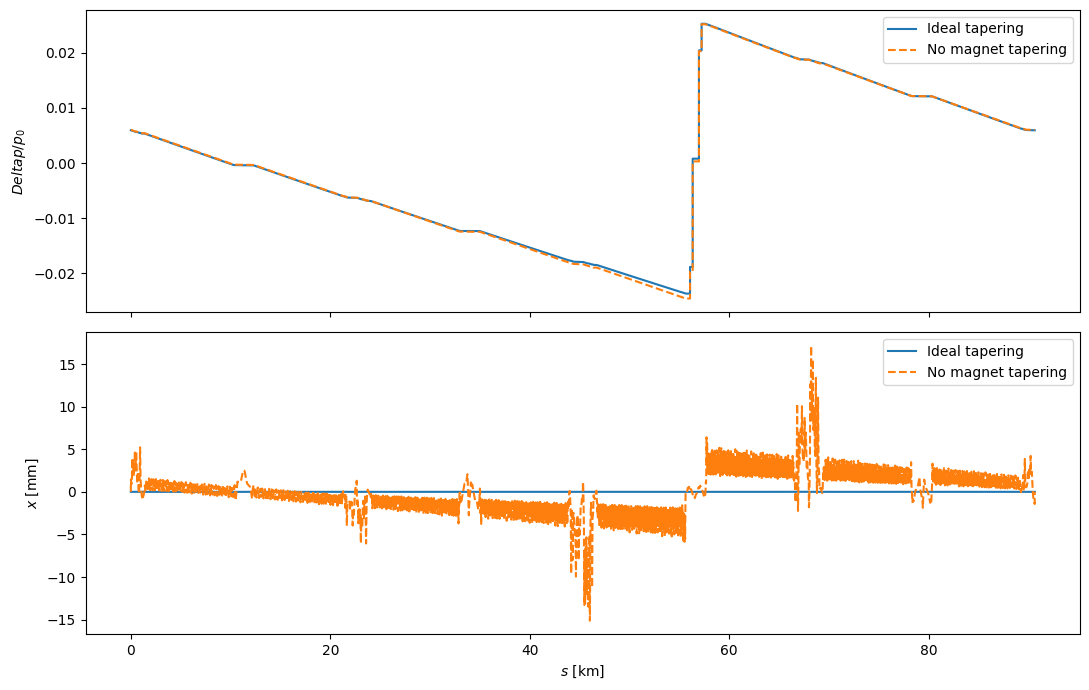

In [13]:
tw_no_taper = line.twiss(eneloss_and_damping=True)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[0].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[0].set_ylabel(
    r"$Delta p/p_0$"
)

axes[0].legend()


axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[1].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.x * 1e3,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[1].set_xlabel(
    r"$s$ [km]"
)

axes[1].set_ylabel(
    r"$x$ [mm]"
)

axes[1].legend()

fig.tight_layout()
plt.show()




In [14]:
# use markers to split into regions
def split_lattice_regions(line):
    ips = ["ipa", "ipb", "ipd", "ipf", "ipg", "iph", "ipj", "ipl"]

    table = line.get_table()
    names = np.asarray(table.name, dtype=str)
    s = np.asarray(table.s, dtype=float)

    valid = names != "_end_point"
    names = names[valid]
    s = s[valid]

    s_by_name = dict(zip(names, s))

    def select(start_marker, end_marker):
        start = s_by_name[start_marker]
        end = s_by_name[end_marker]

        if start <= end:
            mask = (s >= start) & (s < end)
        else:
            mask = (s >= start) | (s < end)

        return names[mask]

    arcs = {}
    arc_ds = {}
    ds = {}
    insertions = {}

    for i, left_ip in enumerate(ips):
        right_ip = ips[(i + 1) % len(ips)]
        sector = f"{left_ip}_{right_ip}"

        arcs[sector] = select(
            f"end_ds_start_arc_{left_ip}",
            f"end_arc_start_ds_{right_ip}",
        )

        arc_ds[sector] = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        right_ds = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_arc_{left_ip}",
        )

        left_ds = select(
            f"end_arc_start_ds_{right_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        ds[sector] = np.concatenate([right_ds, left_ds])

        insertions[right_ip] = select(
            f"end_ds_start_straight_{right_ip}",
            f"end_straight_start_ds_{right_ip}",
        )

    return {
        "arcs": arcs,
        "arc_ds": arc_ds,
        "ds": ds,
        "insertions": insertions,
    }

regions = split_lattice_regions(line)
regions


{'arcs': {'ipa_ipb': array(['bpm_qd1am.0', 'end_ds_start_arc_ipa', 'qd1am.0', ...,
         '||drift_30::323', 'bpm_qd1am.50', 'qd1am.50'],
        shape=(3053,), dtype='<U25'),
  'ipb_ipd': array(['end_ds_start_arc_ipb', 'qd1am.52', 'bpm_qd1am.52', ...,
         'mbd.1634', '||drift_36::287', 'qd1am.102'],
        shape=(3052,), dtype='<U25'),
  'ipd_ipf': array(['bpm_qd1am.104', 'end_ds_start_arc_ipd', 'qd1am.104', ...,
         '||drift_36::938', 'bpm_qd1am.154', 'qd1am.154'],
        shape=(3053,), dtype='<U25'),
  'ipf_ipg': array(['end_ds_start_arc_ipf', 'qd1am.156', 'bpm_qd1am.156', ...,
         'mbd.3314', '||drift_36::1473', 'qd1am.206'],
        shape=(3052,), dtype='<U25'),
  'ipg_iph': array(['bpm_qd1am.208', 'end_ds_start_arc_ipg', 'qd1am.208', ...,
         '||drift_36::2118', 'bpm_qd1am.258', 'qd1am.258'],
        shape=(3053,), dtype='<U25'),
  'iph_ipj': array(['end_ds_start_arc_iph', 'qd1am.260', 'bpm_qd1am.260', ...,
         'mbd.4934', '||drift_89::9', 'qd1am.310'

In [15]:
regions["insertions"]

{'ipb': array(['end_ds_start_straight_ipb', '||drift_30::350', 'bpm_qd6i',
        'hcor_qd6i', 'vcor_qd6i', 'qd6i', '||drift_39::0', 'bpm_qf7i',
        'hcor_qf7i', 'vcor_qf7i', 'qf7i', '||drift_39::1', 'bpm_qd8i',
        'hcor_qd8i', 'vcor_qd8i', 'qd8i', '||drift_39::2', 'bpm_qf9i',
        'hcor_qf9i', 'vcor_qf9i', 'qf9i', '||drift_40::0', 'di0l',
        '||drift_30::351', 'bpm_qd10i', 'hcor_qd10i', 'vcor_qd10i',
        'qd10i', '||drift_41::0', 'bpm_qf11i', 'hcor_qf11i', 'vcor_qf11i',
        'inj_kick1.0', 'qf11i', '||drift_30::352', 'mbd1_inj.0',
        'mbd1_inj.1', 'mbd1_inj.2', '||drift_42', 'mbd2_inj.0',
        'mbd2_inj.1', 'mbd2_inj.2', '||drift_30::353', 'bpm_qd12i',
        'hcor_qd12i', 'vcor_qd12i', 'qd12i', '||drift_43::0', 'bpm_qf13i',
        'hcor_qf13i', 'vcor_qf13i', 'inj_kick2.0', 'qf13i',
        '||drift_106::0', 'septum', '||drift_106::1', 'qf13j', 'bpm_qf13j',
        'hcor_qf13j', 'vcor_qf13j', 'inj_kick2.1', '||drift_43::1',
        'qd12j', 'bpm_qd12

# Step 1: set insertions to perfect tapering

In [16]:
clear_delta_taper(line, elements_with_taper)

# make it flat for all inserions
insertion_element_names_flat = np.concatenate(list(regions["insertions"].values()))

# filter only the elements that have tapering
insertion_mask = np.isin(elements_with_taper,insertion_element_names_flat)

insertion_elements_with_taper = elements_with_taper[insertion_mask]
insertion_ideal_delta_taper = ideal_delta_taper[insertion_mask]

restore_ideal_tapering(line, insertion_elements_with_taper, insertion_ideal_delta_taper)
get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
rf_phase_insertions = read_rf_phase(line)

print(f"Restored ideal tapering for " f"{len(insertion_elements_with_taper)} insertion elements.")
rf_phase_insertions

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 0.397 eV             
Energy loss: 0.028 eV             
Energy loss: 187_227_629.333 eV             
Energy loss: 30_859_910.916 eV             
Energy loss: -8_193_206.483 eV             
Energy loss: -3_540_866.837 eV             
Energy loss: -2_868.289 eV             
Energy loss: 250_680.909 eV             
Energy loss: 41_550.548 eV             
Energy loss: -10_927.728 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             
Energy loss: 335.530 eV             
Energy loss: 5

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103168,-63.206845
1,rf800.0,4020.0,-1.103153,-63.206010
2,rf800.1,4020.0,-1.103153,-63.206010
3,rf400.1,990.0,-1.103168,-63.206845


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

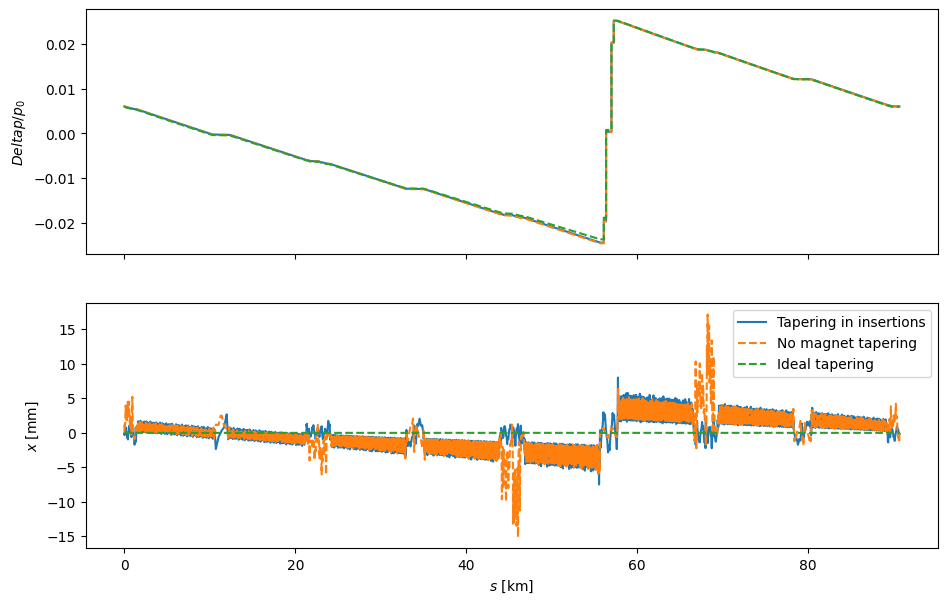

In [17]:
# twiss and plot orbit
twiss_insertion_taper = line.twiss(eneloss_and_damping=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.x * 1e3,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.x * 1e3,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)
plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Define circuits

In [18]:
import re
import numpy as np
import pandas as pd


def define_arc_circuits(line, regions):
    table = line.get_table()

    type_by_name = dict(
        zip(
            np.asarray(table.name, dtype=str),
            np.asarray(table.element_type, dtype=str),
        )
    )

    taperable = {
        name
        for name in line.element_names
        if hasattr(line[name], "delta_taper")
    }

    def family(name):
        # qf2a.15 -> qf2a
        # sf1a.32 -> sf1a
        return re.sub(r"\.\d+$", "", name.lower())

    def select(elements, element_type=None, prefix=None):
        selected = []

        for name in elements:
            if name not in taperable:
                continue

            if element_type is not None:
                if element_type not in type_by_name.get(name, ""):
                    continue

            if prefix is not None:
                prefixes = (
                    (prefix,)
                    if isinstance(prefix, str)
                    else tuple(prefix)
                )

                if not family(name).startswith(prefixes):
                    continue

            selected.append(name)

        return np.asarray(selected, dtype=str)

    def split_in_two(elements):
        """
        Split an ordered family into two contiguous circuits.

        The first circuit contains the first half of the magnets along s.
        The second circuit contains the remaining magnets.
        """
        elements = np.asarray(elements, dtype=str)

        first, second = np.array_split(elements, 2)

        return first, second

    circuits = {}

    for sector in regions["arcs"]:

        arc_elements = regions["arcs"][sector]
        arc_ds_elements = regions["arc_ds"][sector]

        # One dipole circuit for the full DS-arc-DS sector.
        circuits[f"DIP_{sector}"] = select(
            arc_ds_elements,
            element_type="Bend",
        )

        # --------------------------------------------------------------
        # Quadrupoles
        #
        # Original circuits:
        #   QF, QD
        #
        # New circuits:
        #   QF_1, QF_2, QD_1, QD_2
        # --------------------------------------------------------------

        qf_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix="qf",
        )

        qd_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix="qd",
        )

        qf_1, qf_2 = split_in_two(qf_elements)
        qd_1, qd_2 = split_in_two(qd_elements)

        circuits[f"QF_1_{sector}"] = qf_1
        circuits[f"QF_2_{sector}"] = qf_2
        circuits[f"QD_1_{sector}"] = qd_1
        circuits[f"QD_2_{sector}"] = qd_2

        # --------------------------------------------------------------
        # Sextupoles
        #
        # Original circuits:
        #   SF1, SF2, SD1, SD2
        #
        # Each family is now divided longitudinally into two circuits,
        # giving eight sextupole circuits per arc.
        # --------------------------------------------------------------

        sextupole_families = {
            "SF1": "sf1a",
            "SF2": "sf2a",
            "SD1": "sd1a",
            "SD2": "sd2a",
        }

        for circuit_family, prefix in sextupole_families.items():

            family_elements = select(
                arc_elements,
                element_type="Sextupole",
                prefix=prefix,
            )

            first, second = split_in_two(family_elements)

            circuits[f"{circuit_family}_1_{sector}"] = first
            circuits[f"{circuit_family}_2_{sector}"] = second

    # Remove empty circuits.
    circuits = {
        name: elements
        for name, elements in circuits.items()
        if len(elements) > 0
    }

    return circuits

In [19]:
circuits = define_arc_circuits(line, regions)

summary = pd.DataFrame([
    {
        "circuit": circuit,
        "number_of_elements": len(elements),
        "first_element": elements[0],
        "last_element": elements[-1],
    }
    for circuit, elements in circuits.items()
])

display(summary)

,circuit,number_of_elements,first_element,last_element
0,DIP_ipa_ipb,840,mbd.0,mbd.839
1,QF_1_ipa_ipb,71,qf5m.0,qf3a.13
2,QF_2_ipa_ipb,70,qf2a.53,qf5i
3,QD_1_ipa_ipb,71,qd6m.0,qd1a.53
4,QD_2_ipa_ipb,70,qd1a.54,qd4i
...,...,...,...,...
99,SF2_2_ipl_ipa,25,sf2a.383,sf2a.407
100,SD1_1_ipl_ipa,25,sd1a.358,sd1a.382
101,SD1_2_ipl_ipa,25,sd1a.383,sd1a.407
102,SD2_1_ipl_ipa,25,sd2a.358,sd2a.382


# Step 2: set dipoles in coarse granularity

In [20]:
def apply_average_circuit_tapering(
    line,
    circuits,
    ideal_taper_by_name,
    circuit_prefixes,
):
    settings = []

    for circuit_name, circuit_elements in circuits.items():

        if not circuit_name.startswith(tuple(circuit_prefixes)):
            continue

        elements = [
            name for name in circuit_elements
            if name in ideal_taper_by_name
        ]

        if len(elements) == 0:
            continue

        ideal_values = np.asarray(
            [ideal_taper_by_name[name] for name in elements],
            dtype=float,
        )

        # I use average
        circuit_value = np.mean(ideal_values)

        for name in elements:
            line[name].delta_taper = float(circuit_value)

        settings.append({
            "circuit": circuit_name,
            "number_of_elements": len(elements),
            "applied_delta_taper": circuit_value,
            "ideal_min": np.min(ideal_values),
            "ideal_max": np.max(ideal_values),
            "maximum_error": np.max(
                np.abs(ideal_values - circuit_value)
            ),
        })

    return pd.DataFrame(settings)

In [21]:
flag_dipoles_coarse = True

if flag_dipoles_coarse:
    dipole_circuit_settings = apply_average_circuit_tapering(
        line,
        circuits,
        ideal_taper_by_name,
        circuit_prefixes=("DIP",),
    )

    display(dipole_circuit_settings)
else:
        
    dipole_element_names_flat = np.concatenate([
        elements
        for circuit_name, elements in circuits.items()
        if circuit_name.startswith("DIP")
    ])

    dipole_mask = np.isin(
        elements_with_taper,
        dipole_element_names_flat,
    )

    dipole_elements_with_taper = elements_with_taper[
        dipole_mask
    ]

    dipole_ideal_delta_taper = ideal_delta_taper[
        dipole_mask
    ]

    restore_ideal_tapering(
        line,
        dipole_elements_with_taper,
        dipole_ideal_delta_taper,
    )

    print(
        "Restored ideal tapering for "
        f"{len(dipole_elements_with_taper)} DS–arc–DS dipoles."
    )

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,DIP_ipa_ipb,840,0.002485,-0.000367,0.005360,0.002874
1,DIP_ipb_ipd,840,-0.003249,-0.006037,-0.000440,0.002809
2,DIP_ipd_ipf,840,-0.009617,-0.012334,-0.006879,0.002738
3,DIP_ipf_ipg,840,-0.015039,-0.017698,-0.012361,0.002678
4,DIP_ipg_iph,840,-0.021113,-0.023708,-0.018501,0.002612
5,DIP_iph_ipj,840,0.022189,0.019107,0.025289,0.003100
6,DIP_ipj_ipl,840,0.015154,0.012155,0.018177,0.003023
7,DIP_ipl_ipa,840,0.009173,0.006244,0.012125,0.002952


Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 0.397 eV             
Energy loss: 0.028 eV             
Energy loss: 187_227_629.333 eV             
Energy loss: 30_859_910.916 eV             
Energy loss: -8_193_206.483 eV             
Energy loss: -3_540_866.837 eV             
Energy loss: -2_868.289 eV             
Energy loss: 250_680.909 eV             
Energy loss: 41_550.548 eV             
Energy loss: -10_927.728 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             
Energy loss: 335.530 eV             
Energy loss: 5

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

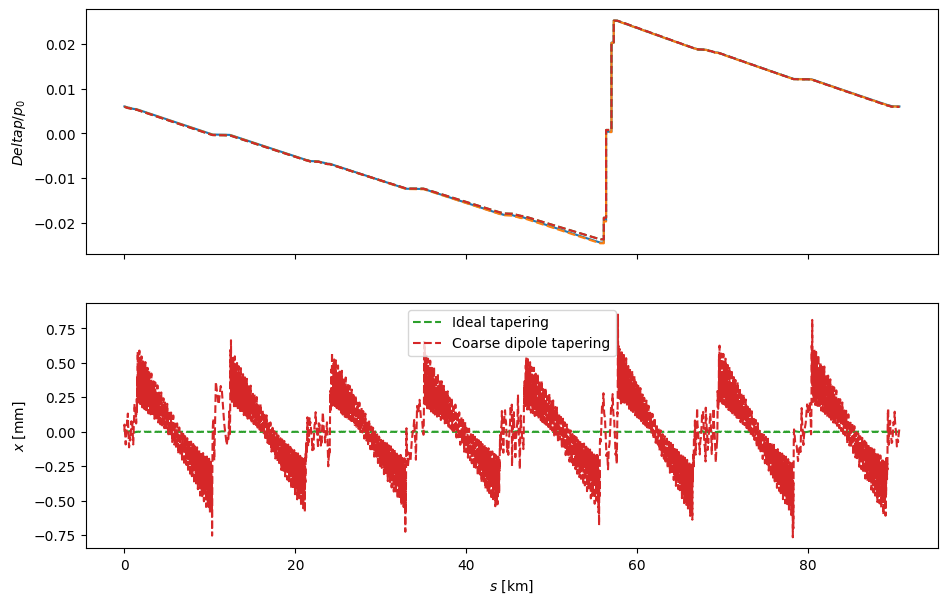

In [22]:
# Recompute the RF phase after changing the dipole tapering.
get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
rf_phase_dipole = read_rf_phase(line)

# Twiss and plot orbit
twiss_dipole = line.twiss(eneloss_and_damping=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])
#plt.plot(
#    twiss_insertion_taper.s / 1e3,
#    twiss_insertion_taper.x * 1e3,
#    color="tab:blue",
#    lw=1.5,
#    label="Tapering in insertions",
#)
#plt.plot(
#    tw_no_taper.s / 1e3,
#    tw_no_taper.x * 1e3,
#    color="tab:orange",
#    ls="--",
#    lw=1.5,
#    label="No magnet tapering",
#)
plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Step 3 set quad and sextupoles in coarse granularity

In [23]:
# Step 2a: quadrupole tapering with circuit granularity

flag_quad_coarse = True

if flag_quad_coarse:
    quadrupole_circuit_settings = apply_average_circuit_tapering(
        line,
        circuits,
        ideal_taper_by_name,
        circuit_prefixes=("QF", "QD"),
    )

    display(quadrupole_circuit_settings)


else:
    # Step 2a: ideal element-by-element quadrupole tapering

    quadrupole_element_names_flat = np.concatenate([
        elements
        for circuit_name, elements in circuits.items()
        if circuit_name.startswith(("QF", "QD"))
    ])

    quadrupole_mask = np.isin(
        elements_with_taper,
        quadrupole_element_names_flat,
    )

    quadrupole_elements_with_taper = elements_with_taper[
        quadrupole_mask
    ]

    quadrupole_ideal_delta_taper = ideal_delta_taper[
        quadrupole_mask
    ]

    restore_ideal_tapering(
        line,
        quadrupole_elements_with_taper,
        quadrupole_ideal_delta_taper,
    )

    print(
        "Restored ideal tapering for "
        f"{len(quadrupole_elements_with_taper)} quadrupoles."
    )

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,QF_1_ipa_ipb,71,0.003918,0.002480,0.005336,0.001438
1,QF_2_ipa_ipb,70,0.001032,-0.000357,0.002439,0.001407
2,QD_1_ipa_ipb,71,0.003939,0.002500,0.005349,0.001438
3,QD_2_ipa_ipb,70,0.001052,-0.000344,0.002459,0.001407
4,QF_1_ipb_ipd,71,-0.001848,-0.003254,-0.000450,0.001406
5,QF_2_ipb_ipd,70,-0.004669,-0.006014,-0.003294,0.001375
6,QD_1_ipb_ipd,71,-0.001868,-0.003274,-0.000463,0.001406
7,QD_2_ipb_ipd,70,-0.004689,-0.006027,-0.003314,0.001375
8,QF_1_ipd_ipf,71,-0.008252,-0.009622,-0.006902,0.001370
9,QF_2_ipd_ipf,70,-0.011001,-0.012325,-0.009661,0.001341


In [24]:
flag_sext_coarse = True

if flag_sext_coarse:
    sextupole_circuit_settings = apply_average_circuit_tapering(
        line,
        circuits,
        ideal_taper_by_name,
        circuit_prefixes=("SF", "SD"),
    )

    display(sextupole_circuit_settings)

else:
    # Step 2b: ideal element-by-element sextupole tapering

    sextupole_element_names_flat = np.concatenate([
        elements
        for circuit_name, elements in circuits.items()
        if circuit_name.startswith(("SF", "SD"))
    ])

    sextupole_mask = np.isin(
        elements_with_taper,
        sextupole_element_names_flat,
    )

    sextupole_elements_with_taper = elements_with_taper[
        sextupole_mask
    ]

    sextupole_ideal_delta_taper = ideal_delta_taper[
        sextupole_mask
    ]

    restore_ideal_tapering(
        line,
        sextupole_elements_with_taper,
        sextupole_ideal_delta_taper,
    )

    print(
        "Restored ideal tapering for "
        f"{len(sextupole_elements_with_taper)} sextupoles."
    )

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,SF1_1_ipa_ipb,25,0.003764,0.002521,0.004991,0.001243
1,SF1_2_ipa_ipb,25,0.001205,-0.000006,0.002439,0.001234
2,SF2_1_ipa_ipb,25,0.003765,0.002562,0.005032,0.001267
3,SF2_2_ipa_ipb,25,0.001203,-0.000046,0.002398,0.001250
4,SD1_1_ipa_ipb,25,0.003765,0.002541,0.005011,0.001247
...,...,...,...,...,...,...
59,SF2_2_ipl_ipa,25,0.007857,0.006573,0.009084,0.001283
60,SD1_1_ipl_ipa,25,0.010487,0.009231,0.011768,0.001281
61,SD1_2_ipl_ipa,25,0.007857,0.006594,0.009105,0.001263
62,SD2_1_ipl_ipa,25,0.010485,0.009189,0.011725,0.001297


In [25]:
get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
rf_phase_quad_sext = read_rf_phase(line)

rf_phase_quad_sext

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 0.397 eV             
Energy loss: 0.028 eV             
Energy loss: 187_227_629.333 eV             
Energy loss: 30_859_910.916 eV             
Energy loss: -8_193_206.483 eV             
Energy loss: -3_540_866.837 eV             
Energy loss: -2_868.289 eV             
Energy loss: 250_680.909 eV             
Energy loss: 41_550.548 eV             
Energy loss: -10_927.728 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             
Energy loss: 335.530 eV             
Energy loss: 5

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103168,-63.206845
1,rf800.0,4020.0,-1.103153,-63.206010
2,rf800.1,4020.0,-1.103153,-63.206010
3,rf400.1,990.0,-1.103168,-63.206845


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

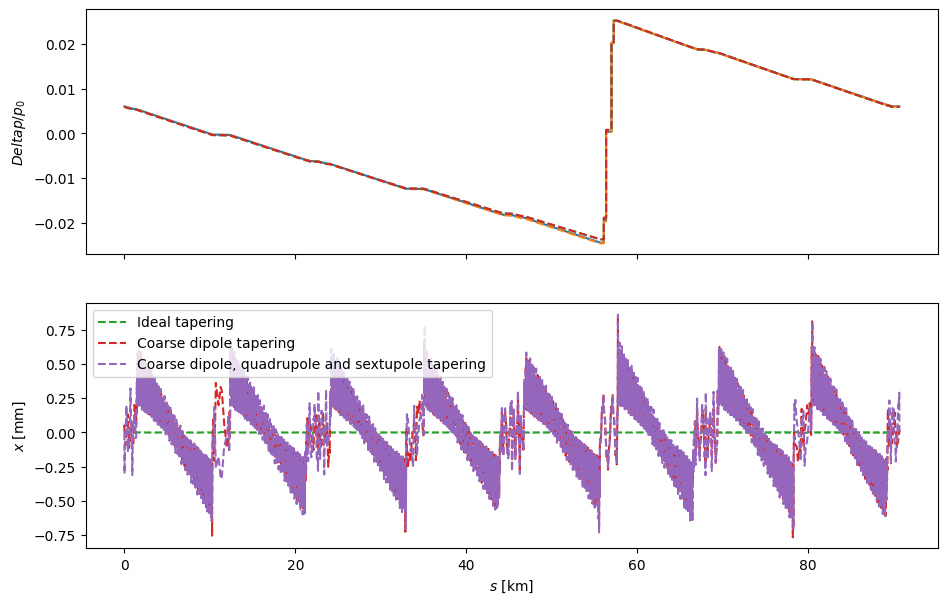

In [26]:
# twiss and plot orbit
twiss_quad_sext = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse quadrupole and sextupole tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])

plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

# dipoles
plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.5,
    label="Coarse dipole, quadrupole and sextupole tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Step 4: correct orbit with orbit correctors

In [27]:
import numpy as np
import xtrack as xt
import pandas as pd


# modified xsuite functions to pass reference orbit, https://github.com/xsuite/xtrack/blob/main/xtrack/trajectory_correction.py

def _compute_correction(x_iter, response_matrix, n_micado=None, rcond=None,
                        n_singular_values=None, gain=1):

    if isinstance(response_matrix, (list, tuple)):
        assert len(response_matrix) == 3  # U, S, Vt
        U, S, Vh = response_matrix
        if n_singular_values is not None:
            U = U[:, :n_singular_values]
            S = S[:n_singular_values]
            Vh = Vh[:n_singular_values, :]
        # The SVD factors are used directly below. Reconstruct the full
        # matrix only when MICADO needs to test individual correctors.
        n_hcorrectors = Vh.shape[1]
        if n_micado is not None:
            response_matrix = U @ np.diag(S) @ Vh
    else:
        assert n_singular_values is None
        U = None
        S = None
        Vh = None
        n_hcorrectors = response_matrix.shape[1]

    if n_micado is not None:
        used_correctors = []
        for i_micado in range(n_micado):
            residuals = []
            for i_corr in range(n_hcorrectors):
                if i_corr in used_correctors:
                    residuals.append(np.nan)
                    continue
                mask_corr = np.zeros(n_hcorrectors, dtype=bool)
                mask_corr[i_corr] = True
                for i_used in used_correctors:
                    mask_corr[i_used] = True
                _, residual_x, rank_x, sval_x = np.linalg.lstsq(
                    response_matrix[:, mask_corr], -x_iter, rcond=rcond)
                residuals.append(residual_x[0])
            used_correctors.append(np.nanargmin(residuals))
        mask_corr = np.zeros(n_hcorrectors, dtype=bool)
        mask_corr[used_correctors] = True
    else:
        mask_corr = np.ones(n_hcorrectors, dtype=bool)
        mask_corr[:] = True

    if mask_corr.all() and S is not None:
        S_inv = np.zeros_like(S)
        S_inv[S > 0] = 1 / S[S > 0]
        if rcond is not None:
            S_inv[S < rcond * S[0]] = 0
        correction_masked = Vh.T.conj() @ (np.diag(S_inv) @ (U.T.conj() @ (-x_iter)))
    else:
        correction_masked, residual_x, rank_x, sval_x = np.linalg.lstsq(
            response_matrix[:, mask_corr], -x_iter, rcond=rcond)
    correction_masked *= gain

    correction_x = np.zeros(n_hcorrectors)
    correction_x[mask_corr] = correction_masked
    return correction_x


def _build_response_matrix(tw, monitor_names, corrector_names,
                           mode='closed', plane=None):
    assert mode in ['closed', 'open']
    assert plane in ['x', 'y']

    indices_monitors   = tw.rows.indices[monitor_names]
    indices_correctors = tw.rows.indices[corrector_names]
    bet_monitors    = tw['bet' + plane][indices_monitors]
    bet_correctors  = tw['bet' + plane][indices_correctors]
    mu_monitor      = tw['mu' + plane][indices_monitors]
    mux_correctors  = tw['mu' + plane][indices_correctors]

    n_monitors   = len(monitor_names)
    n_correctors = len(corrector_names)

    bet_prod = np.atleast_2d(bet_monitors).T @ np.atleast_2d(bet_correctors)
    # Broadcasting avoids two full-size temporary tiled arrays.
    mu_diff = mu_monitor[:, None] - mux_correctors[None, :]

    if mode == 'open':
        mu_diff[mu_diff < 0] = 0
        response_matrix = (np.sqrt(bet_prod) * np.sin(2 * np.pi * np.abs(mu_diff)))
    elif mode == 'closed':
        #tune = tw.qx
        if plane == 'x':
            tune = tw.qx
        elif plane == 'y':
            tune = tw.qy
            
        response_matrix = (np.sqrt(bet_prod) / 2 / np.sin(np.pi * tune)
                           * np.cos(np.pi * tune - 2 * np.pi * np.abs(mu_diff)))
    return response_matrix


class OrbitCorrectionSinglePlane:

    def __init__(self, line, plane, monitor_names, corrector_names,
                 start=None, end=None, twiss_table=None, n_micado=None,
                 n_singular_values=None, rcond=None, reference_orbit=None):

        assert plane in ['x', 'y']
        self.twiss_table = twiss_table
        if twiss_table is not None:
            assert twiss_table.reference_frame == 'proper'
        self.reference_orbit = reference_orbit

        if start is None:
            assert end is None
            self.mode = 'closed'
            if self.twiss_table is None:
                self.twiss_table = line.twiss4d(reverse=False)
        else:
            assert end is not None
            self.mode = 'open'
            if self.twiss_table is None:
                self.twiss_table = line.twiss4d(
                    start=start, end=end,
                    init=xt.TwissInit(W_matrix=np.eye(6),
                                      particle_on_co=line.build_particles(
                                          x=0, y=0, px=0, py=0, zeta=0, delta=0),
                                      element_name=start),
                    reverse=False)

        if corrector_names is None:
            corr_names_from_line = getattr(line, f'steering_correctors_{plane}')
            assert corr_names_from_line is not None
            if start is not None:
                corrector_names = [nn for nn in corr_names_from_line
                                   if nn in self.twiss_table.name]
            else:
                corrector_names = corr_names_from_line

        if monitor_names is None:
            monitor_names = getattr(line, f'steering_monitors_{plane}')
            assert monitor_names is not None
            if start is not None:
                monitor_names = [nn for nn in monitor_names
                                 if nn in self.twiss_table.name]

        assert len(monitor_names) > 0
        assert len(corrector_names) > 0

        self.line            = line
        self.plane           = plane
        self.monitor_names   = monitor_names
        self.corrector_names = corrector_names
        self.start           = start
        self.end             = end
        self.n_micado        = n_micado
        self.rcond           = rcond
        self.n_singular_values = n_singular_values

        self.response_matrix = _build_response_matrix(
            plane=self.plane, tw=self.twiss_table,
            monitor_names=self.monitor_names,
            corrector_names=self.corrector_names, mode=self.mode)

        U, S, Vt = np.linalg.svd(self.response_matrix, full_matrices=False)
        self.singular_values      = S
        self.singular_vectors_out = U
        self.singular_vectors_in  = Vt

        tw_table_local = self.twiss_table.rows[start:end]
        self._indices_monitor    = tw_table_local.rows.indices[self.monitor_names]
        self._indices_correctors = tw_table_local.rows.indices[self.corrector_names]
        self.s_correctors        = tw_table_local.s[self._indices_correctors]
        self.s_monitors          = tw_table_local.s[self._indices_monitor]

        self._add_correction_knobs()

    def set_reference_orbit_from_twiss(self, tw):
        indices = tw.rows.indices[self.monitor_names]
        self.reference_orbit = np.asarray(tw[self.plane][indices], dtype=float).copy()

    def _compute_tw_orbit(self):
        twinit = None
        if self.mode == 'open':
            twinit = xt.TwissInit(
                W_matrix=np.eye(6),
                particle_on_co=self.line.build_particles(
                    x=0, y=0, px=0, py=0, zeta=0, delta=0),
                element_name=self.start)
        #return self.line.twiss4d(only_orbit=True, start=self.start,
        #                         end=self.end, init=twinit, reverse=False)
        return self.line.twiss(only_orbit=True, start=self.start,
                               end=self.end, init=twinit, reverse=False)

    def _measure_position(self, tw_orbit=None):
        if tw_orbit is None:
            tw_orbit = self._compute_tw_orbit()
        indices = tw_orbit.rows.indices[self.monitor_names]
        position = np.asarray(tw_orbit[self.plane][indices], dtype=float)
        if self.reference_orbit is not None:
            assert len(self.reference_orbit) == len(position)
            position = position - self.reference_orbit
        return position

    def _compute_correction(self, position, n_micado=None,
                            n_singular_values=None, rcond=None, gain=1):
        if rcond is None:
            rcond = self.rcond
        if n_singular_values is None:
            n_singular_values = self.n_singular_values
        if n_micado is None:
            n_micado = self.n_micado
        return _compute_correction(
            position,
            response_matrix=(self.singular_vectors_out,
                             self.singular_values,
                             self.singular_vectors_in),
            n_micado=n_micado, rcond=rcond,
            n_singular_values=n_singular_values, gain=gain)

    def _add_correction_knobs(self):
        self.correction_knobs = []
        for nn_kick in self.corrector_names:
            corr_knob_name = f'orbit_corr_{nn_kick}_{self.plane}'
            assert hasattr(self.line[nn_kick], 'knl')
            assert hasattr(self.line[nn_kick], 'ksl')
            if corr_knob_name not in self.line.vars:
                self.line.vars[corr_knob_name] = 0
            if self.plane == 'x':
                if (self.line.element_refs[nn_kick].knl[0]._expr is None or
                    (self.line.vars[corr_knob_name]
                     not in self.line.element_refs[nn_kick].knl[0]._expr._get_dependencies())):
                    if self.line.element_refs[nn_kick].knl[0]._expr is not None:
                        self.line.element_refs[nn_kick].knl[0] -= (
                            self.line.vars[f'orbit_corr_{nn_kick}_x'])
                    else:
                        val = self.line.element_refs[nn_kick].knl[0]._value
                        if hasattr(val, 'get'):
                            val = val.get()
                        self.line.element_refs[nn_kick].knl[0] = val - (
                            self.line.vars[f'orbit_corr_{nn_kick}_x'])
            elif self.plane == 'y':
                if (self.line.element_refs[nn_kick].ksl[0]._expr is None or
                    (self.line.vars[corr_knob_name]
                     not in self.line.element_refs[nn_kick].ksl[0]._expr._get_dependencies())):
                    if self.line.element_refs[nn_kick].ksl[0]._expr is not None:
                        self.line.element_refs[nn_kick].ksl[0] += (
                            self.line.vars[f'orbit_corr_{nn_kick}_y'])
                    else:
                        val = self.line.element_refs[nn_kick].ksl[0]._value
                        if hasattr(val, 'get'):
                            val = val.get()
                        self.line.element_refs[nn_kick].ksl[0] = val + (
                            self.line.vars[f'orbit_corr_{nn_kick}_y'])
            self.correction_knobs.append(corr_knob_name)

    def _apply_correction(self, correction=None):
        if correction is None:
            correction = self.correction
        for nn_knob, kick in zip(self.correction_knobs, correction):
            self.line.vars[nn_knob] += kick

    def get_kick_values(self):
        return np.array([self.line.vv[nn_knob] for nn_knob in self.correction_knobs])

    def clear_correction_knobs(self):
        for nn_knob in self.correction_knobs:
            self.line.vars[nn_knob] = 0


class TrajectoryCorrection:

    def __init__(self, line, start=None, end=None, twiss_table=None,
                 monitor_names_x=None, corrector_names_x=None,
                 monitor_names_y=None, corrector_names_y=None,
                 n_micado=None, n_singular_values=None, rcond=None):

        if isinstance(rcond, (tuple, list)):
            rcond_x, rcond_y = rcond
        else:
            rcond_x, rcond_y = rcond, rcond
        if isinstance(n_singular_values, (tuple, list)):
            n_singular_values_x, n_singular_values_y = n_singular_values
        else:
            n_singular_values_x, n_singular_values_y = n_singular_values, n_singular_values
        if isinstance(n_micado, (tuple, list)):
            n_micado_x, n_micado_y = n_micado
        else:
            n_micado_x, n_micado_y = n_micado, n_micado

        if (monitor_names_x is not None or corrector_names_x is not None
                or line.steering_correctors_x is not None
                or line.steering_monitors_x is not None):
            self.x_correction = OrbitCorrectionSinglePlane(
                line=line, plane='x', monitor_names=monitor_names_x,
                corrector_names=corrector_names_x, start=start, end=end,
                twiss_table=twiss_table, n_micado=n_micado_x,
                n_singular_values=n_singular_values_x, rcond=rcond_x)
        else:
            self.x_correction = None

        if (monitor_names_y is not None or corrector_names_y is not None
                or line.steering_correctors_y is not None
                or line.steering_monitors_y is not None):
            self.y_correction = OrbitCorrectionSinglePlane(
                line=line, plane='y', monitor_names=monitor_names_y,
                corrector_names=corrector_names_y, start=start, end=end,
                twiss_table=twiss_table, n_micado=n_micado_y,
                n_singular_values=n_singular_values_y, rcond=rcond_y)
        else:
            self.y_correction = None

    def clear_correction_knobs(self):
        if self.x_correction is not None:
            self.x_correction.clear_correction_knobs()
        if self.y_correction is not None:
            self.y_correction.clear_correction_knobs()

    @property
    def line(self):
        if self.x_correction is not None:
            return self.x_correction.line
        return self.y_correction.line

    @property
    def twiss_table(self):
        if self.x_correction is not None:
            return self.x_correction.twiss_table
        return self.y_correction.twiss_table

In [28]:
# BPMs
tt_monitors     = tt.rows['bpm.*']
monitor_names   = tt_monitors.name
monitor_s       = tt_monitors.s
print(f"\nBPMs: {len(monitor_names)}")

# Correctors
tt_multi            = tt.rows[tt.element_type == 'Multipole']
tt_h_correctors = tt_multi.rows['hcor.*']
tt_v_correctors = tt_multi.rows['vcor.*']
h_corrector_names = tt_h_correctors.name;  h_corrector_s = tt_h_correctors.s
v_corrector_names = tt_v_correctors.name;  v_corrector_s = tt_v_correctors.s
print(f"H correctors: {len(h_corrector_names)}")
print(f"V correctors: {len(v_corrector_names)}")



BPMs: 2636
H correctors: 2252
V correctors: 2252


In [29]:
# Set steering elements
line.steering_correctors_x = h_corrector_names
line.steering_correctors_y = v_corrector_names
line.steering_monitors_x   = monitor_names
line.steering_monitors_y   = monitor_names
print("Steering elements set.")

Steering elements set.


In [30]:
feedback_n_singular = None
correction = TrajectoryCorrection(
    line=line,                    # Current, imperfect/coarsely tapered line
    twiss_table=twiss_ideal,      # Ideal lattice optics
    monitor_names_x=monitor_names,
    corrector_names_x=h_corrector_names,
    monitor_names_y=monitor_names,
    corrector_names_y=v_corrector_names,
    n_singular_values=feedback_n_singular,
)
correction.x_correction.set_reference_orbit_from_twiss(twiss_ideal)
correction.y_correction.set_reference_orbit_from_twiss(twiss_ideal)

In [31]:
def correct_orbit_iteratively(
    correction,
    tolerance_x=1e-6,
    tolerance_y=1e-6,
    max_iterations=10,
    n_singular_values=None,
    rcond=1e-3,
    gain=1.0,
):
    """
    Iteratively correct x and y toward the stored reference orbit.

    tolerance_x, tolerance_y:
        RMS BPM residual in metres.

    gain:
        Fraction of the calculated correction applied per iteration.
        Use 1.0 normally; reduce to 0.5 if convergence oscillates.
    """

    x_corr = correction.x_correction
    y_corr = correction.y_correction

    history = []

    for iteration in range(max_iterations + 1):

        # Recompute the present orbit after the previous correction
        twiss_orbit = x_corr._compute_tw_orbit()

        # These already return:
        # current BPM orbit - reference BPM orbit
        residual_x = x_corr._measure_position(
            twiss_orbit
        )

        residual_y = y_corr._measure_position(
            twiss_orbit
        )

        rms_x = np.sqrt(np.mean(residual_x**2))
        rms_y = np.sqrt(np.mean(residual_y**2))

        max_x = np.max(np.abs(residual_x))
        max_y = np.max(np.abs(residual_y))

        history.append({
            "iteration": iteration,
            "x_rms_m": rms_x,
            "y_rms_m": rms_y,
            "x_max_m": max_x,
            "y_max_m": max_y,
        })

        print(
            f"Iteration {iteration}: "
            f"x RMS = {rms_x * 1e6:.4f} um, "
            f"y RMS = {rms_y * 1e6:.4f} um"
        )

        converged_x = rms_x <= tolerance_x
        converged_y = rms_y <= tolerance_y

        if converged_x and converged_y:
            print("Orbit correction converged.")
            break

        if iteration == max_iterations:
            print("Maximum number of iterations reached.")
            break

        # Horizontal correction
        if not converged_x:
            delta_kick_x = x_corr._compute_correction(
                position=residual_x,
                n_singular_values=n_singular_values,
                rcond=rcond,
                gain=gain,
            )

            x_corr._apply_correction(
                delta_kick_x
            )

        # Vertical correction
        if not converged_y:
            delta_kick_y = y_corr._compute_correction(
                position=residual_y,
                n_singular_values=n_singular_values,
                rcond=rcond,
                gain=gain,
            )

            y_corr._apply_correction(
                delta_kick_y
            )

    return pd.DataFrame(history)

In [32]:
correction_history = correct_orbit_iteratively(
    correction=correction,
    tolerance_x=1e-6,          # 1 um
    tolerance_y=1e-6,          # 1 um
    max_iterations=10,
    n_singular_values=feedback_n_singular,
    rcond=1e-6,
    gain=1.0,
)

display(correction_history)

Iteration 0: x RMS = 232.6445 um, y RMS = 0.0000 um
Iteration 1: x RMS = 32.2912 um, y RMS = 0.0000 um
Iteration 2: x RMS = 28.7493 um, y RMS = 0.0000 um
Iteration 3: x RMS = 28.7382 um, y RMS = 0.0000 um
Iteration 4: x RMS = 28.7381 um, y RMS = 0.0000 um
Iteration 5: x RMS = 28.7381 um, y RMS = 0.0000 um
Iteration 6: x RMS = 28.7381 um, y RMS = 0.0000 um
Iteration 7: x RMS = 28.7382 um, y RMS = 0.0000 um
Iteration 8: x RMS = 28.7382 um, y RMS = 0.0000 um
Iteration 9: x RMS = 28.7382 um, y RMS = 0.0000 um
Iteration 10: x RMS = 28.7382 um, y RMS = 0.0000 um
Maximum number of iterations reached.


,iteration,x_rms_m,y_rms_m,x_max_m,y_max_m
0,0,0.000233,4.993456e-13,0.000861,3.313757e-12
1,1,0.000032,8.040995e-13,0.000124,4.678966e-12
2,2,0.000029,8.369881e-13,0.000114,4.828769e-12
3,3,0.000029,8.842473e-13,0.000114,5.098334e-12
4,4,0.000029,9.326597e-13,0.000114,5.374138e-12
5,5,0.000029,9.824183e-13,0.000114,5.657451e-12
6,6,0.000029,1.033577e-12,0.000114,5.948530e-12
7,7,0.000029,1.086181e-12,0.000114,6.247696e-12
8,8,0.000029,1.140246e-12,0.000114,6.554885e-12
9,9,0.000029,1.195829e-12,0.000114,6.870546e-12


In [33]:
twiss_after_correction = line.twiss(eneloss_and_damping=True, radiation_analysis=True)

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

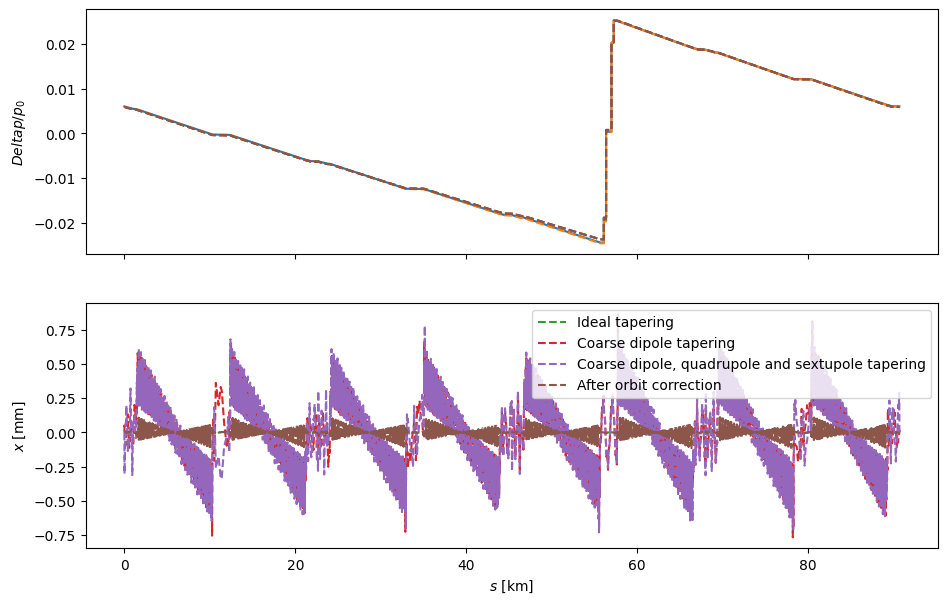

In [34]:

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse quadrupole and sextupole tapering",
)

plt.plot(
    twiss_after_correction.s / 1e3,
    twiss_after_correction.delta,
    color="tab:brown",
    ls="--",
    lw=1.5,
    label="After orbit correction",
)


plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])

plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

# dipoles
plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.5,
    label="Coarse dipole, quadrupole and sextupole tapering",
)

plt.plot(
    twiss_after_correction.s / 1e3,
    twiss_after_correction.x * 1e3,
    color="tab:brown",
    ls="--",
    lw=1.5,
    label="After orbit correction",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

In [35]:
twiss_scenario_1_before_correction = twiss_quad_sext # this is the one with dipoles, quads, sexts coarse but no orbit correction yet
twiss_scenario_1_after_correction = twiss_after_correction

In [36]:
beta_beating_x = (
    twiss_scenario_1_after_correction.betx - twiss_ideal.betx
) / twiss_ideal.betx

beta_beating_y = (
    twiss_scenario_1_after_correction.bety - twiss_ideal.bety
) / twiss_ideal.bety


diagnostics = pd.DataFrame({
    "name": np.asarray(twiss_scenario_1_after_correction.name, dtype=str),
    "s_km": np.asarray(twiss_scenario_1_after_correction.s) / 1e3,
    "beta_beating_x": beta_beating_x,
    "beta_beating_y": beta_beating_y,
    "orbit_x_mm": (
        twiss_scenario_1_after_correction.x - twiss_ideal.x
    ) * 1e3,
})


print("Largest horizontal beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_x))[-15:]
    ].sort_values(
        "beta_beating_x",
        key=np.abs,
        ascending=False,
    )
)


print("Largest vertical beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_y))[-15:]
    ].sort_values(
        "beta_beating_y",
        key=np.abs,
        ascending=False,
    )
)

Largest horizontal beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
9688,||drift_36::722,29.052181,0.020159,0.014798,0.000253
9689,sd1a.130,29.052331,0.020145,0.014829,0.000192
9648,mbd.2139,28.927201,0.020114,0.019738,0.000186
9647,||drift_36::715,28.927051,0.020068,0.019746,0.000139
9692,vcor_qd1a.276,29.052851,0.020048,0.014932,-0.000019
9691,hcor_qd1a.276,29.052851,0.020048,0.014932,-0.000019
9693,||drift_34::256,29.052851,0.020048,0.014932,-0.000019
9690,bpm_qd1a.276,29.052851,0.020048,0.014932,-0.000019
9694,qd1a.276,29.052951,0.020020,0.014952,0.000022
11079,||drift_36::950,32.699391,-0.019863,0.002607,-0.080823


Largest vertical beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
25495,||drift_78::424,76.397770,-0.013290,0.039812,0.033959
25497,qf3a.183,76.397920,-0.013310,0.039806,0.034089
25496,bpm_qf3a.183,76.397920,-0.013310,0.039806,0.034089
23546,||drift_78::202,71.281930,-0.005315,-0.038654,-0.034140
25498,||drift_78::425,76.400810,-0.013675,0.038637,0.034183
23547,mbd.5160,71.282080,-0.005341,-0.038622,-0.034017
25377,mbd.5610,76.081030,-0.007581,0.038529,0.029808
25499,mbd.5640,76.400960,-0.013695,0.038526,0.034063
25376,||drift_78::406,76.080880,-0.007619,0.038448,0.029912
23544,bpm_qf3a.167,71.279040,-0.004796,-0.038035,-0.034107


In [37]:
def twiss_scalar(twiss, *candidate_names):
    for name in candidate_names:
        value = getattr(twiss, name, None)
        if value is not None:
            array = np.asarray(value)
            if array.size:
                return float(array.reshape(-1)[0])
    return np.nan

def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.nanmean(values**2)))

def max_abs(values):
    return float(np.nanmax(np.abs(np.asarray(values, dtype=float))))

def percent_change(value, reference):
    if not np.isfinite(reference) or reference == 0:
        return np.nan
    return 100.0 * (value/reference - 1.0)

def complete_optics_summary(twiss, reference):
    betx_beating = (twiss.betx-reference.betx)/reference.betx
    bety_beating = (twiss.bety-reference.bety)/reference.bety
    delta_x = twiss.x-reference.x
    delta_y = twiss.y-reference.y
    delta_dx = twiss.dx-reference.dx
    delta_dy = twiss.dy-reference.dy

    emit_x = twiss_scalar(twiss, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y = twiss_scalar(twiss, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')
    emit_x_ref = twiss_scalar(reference, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y_ref = twiss_scalar(reference, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')

    return {
        'Horizontal tune Qx': twiss_scalar(twiss, 'qx'),
        'Vertical tune Qy': twiss_scalar(twiss, 'qy'),
        'Horizontal tune shift': twiss_scalar(twiss, 'qx')-twiss_scalar(reference, 'qx'),
        'Vertical tune shift': twiss_scalar(twiss, 'qy')-twiss_scalar(reference, 'qy'),
        'Horizontal chromaticity Qx_prime': twiss_scalar(twiss, 'dqx'),
        'Vertical chromaticity Qy_prime': twiss_scalar(twiss, 'dqy'),
        'Minimum tune separation |C-|': twiss_scalar(twiss, 'c_minus'),
        'Synchrotron tune Qs': twiss_scalar(twiss, 'qs'),
        'RMS beta-x beating [%]': 100*rms(betx_beating),
        'Maximum beta-x beating [%]': 100*max_abs(betx_beating),
        'RMS beta-y beating [%]': 100*rms(bety_beating),
        'Maximum beta-y beating [%]': 100*max_abs(bety_beating),
        'RMS horizontal-orbit residual [um]': 1e6*rms(delta_x),
        'Maximum horizontal-orbit residual [um]': 1e6*max_abs(delta_x),
        'RMS vertical-orbit residual [um]': 1e6*rms(delta_y),
        'Maximum vertical-orbit residual [um]': 1e6*max_abs(delta_y),
        'RMS horizontal-dispersion residual [mm]': 1e3*rms(delta_dx),
        'Maximum horizontal-dispersion residual [mm]': 1e3*max_abs(delta_dx),
        'RMS vertical-dispersion residual [mm]': 1e3*rms(delta_dy),
        'Maximum vertical-dispersion residual [mm]': 1e3*max_abs(delta_dy),
        'Equilibrium horizontal emittance [nm]': 1e9*emit_x,
        'Horizontal emittance change [%]': percent_change(emit_x, emit_x_ref),
        'Equilibrium vertical emittance [pm]': 1e12*emit_y,
        'Vertical emittance change [%]': percent_change(emit_y, emit_y_ref),
        'Equilibrium longitudinal emittance [um]': 1e6*twiss_scalar(
            twiss, 'eq_gemitt_zeta', 'rad_int_eq_gemitt_zeta'),
        'Equilibrium momentum spread [%]': 100*twiss_scalar(
            twiss, 'eq_sigma_delta', 'rad_int_sigma_delta'),
        'Equilibrium bunch length [mm]': 1e3*twiss_scalar(
            twiss, 'eq_sigma_zeta', 'eq_sigma_z', 'rad_int_sigma_zeta'),
        'Energy loss per turn [GeV]': 1e-9*twiss_scalar(
            twiss, 'eneloss_turn', 'rad_int_energy_loss'),
        'Momentum compaction factor': twiss_scalar(
            twiss, 'momentum_compaction_factor'),
        'Slip factor': twiss_scalar(twiss, 'slip_factor'),
    }

optics_comparison = pd.DataFrame({
    'Ideal tapering': complete_optics_summary(twiss_ideal, twiss_ideal),
    'Scenario 1 before correction': complete_optics_summary(
        twiss_scenario_1_before_correction, twiss_ideal),
    'Scenario 1 after correction': complete_optics_summary(
        twiss_after_correction, twiss_ideal),
})
pd.set_option('display.max_rows', None)
display(optics_comparison)

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:3761: FutureWarning: `eneloss_turn` is deprecated, use `energy_loss` instead. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn(object.__getattribute__(self, '_DEPRECATED_FIELDS')[name], FutureWarning)


,Ideal tapering,Scenario 1 before correction,Scenario 1 after correction
Horizontal tune Qx,3.461316e+02,3.461398e+02,3.461321e+02
Vertical tune Qy,2.622813e+02,2.622788e+02,2.622882e+02
Horizontal tune shift,0.000000e+00,8.156060e-03,4.486917e-04
Vertical tune shift,0.000000e+00,-2.447030e-03,6.881013e-03
Horizontal chromaticity Qx_prime,4.605618e+00,4.565509e+00,4.600064e+00
Vertical chromaticity Qy_prime,3.873636e+00,3.750051e+00,3.829909e+00
Minimum tune separation |C-|,1.946384e-10,2.728271e-10,3.068613e-10
Synchrotron tune Qs,9.183682e-02,9.179464e-02,9.183788e-02
RMS beta-x beating [%],0.000000e+00,2.725167e+00,8.986102e-01
Maximum beta-x beating [%],0.000000e+00,6.206268e+00,2.015893e+00


In [38]:
# Focused equilibrium-emittance comparison.
emittance_rows = [
    'Equilibrium horizontal emittance [nm]',
    'Horizontal emittance change [%]',
    'Equilibrium vertical emittance [pm]',
    'Vertical emittance change [%]',
    'Equilibrium momentum spread [%]',
    'Equilibrium bunch length [mm]',
]
display(optics_comparison.loc[emittance_rows])

,Ideal tapering,Scenario 1 before correction,Scenario 1 after correction
Equilibrium horizontal emittance [nm],2.189257,2.190525,2.191117
Horizontal emittance change [%],0.000000,0.057915,0.084990
Equilibrium vertical emittance [pm],0.063788,0.063755,0.064079
Vertical emittance change [%],0.000000,-0.051562,0.456486
Equilibrium momentum spread [%],NaN,NaN,NaN
Equilibrium bunch length [mm],NaN,NaN,NaN


# Horizontal optics comparison for every case

The dispersion is compared directly with the ideal lattice. The beta beating is shown as the relative difference from the ideal horizontal beta function.

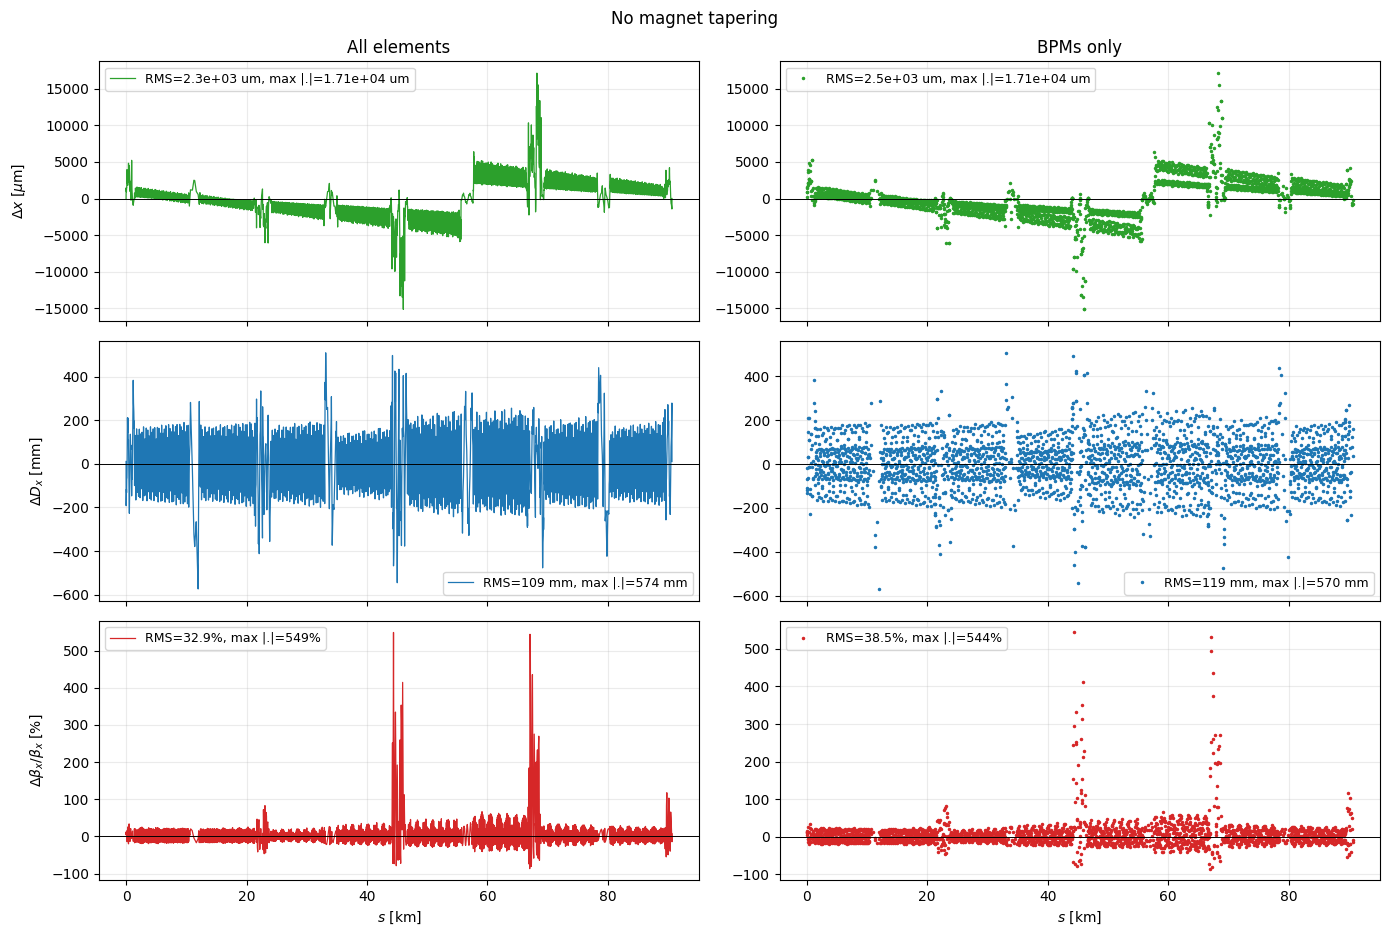

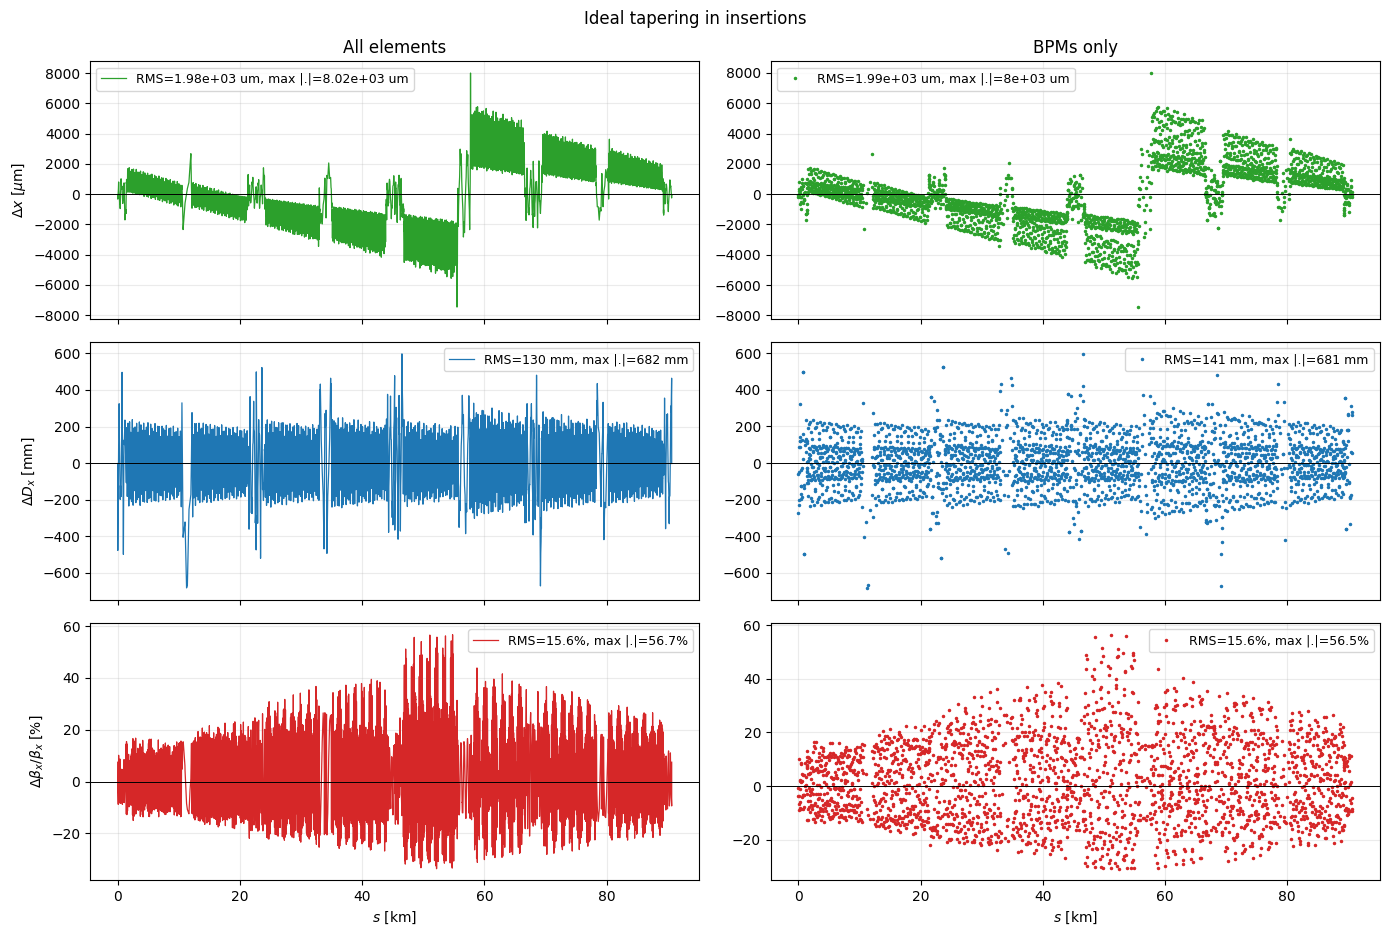

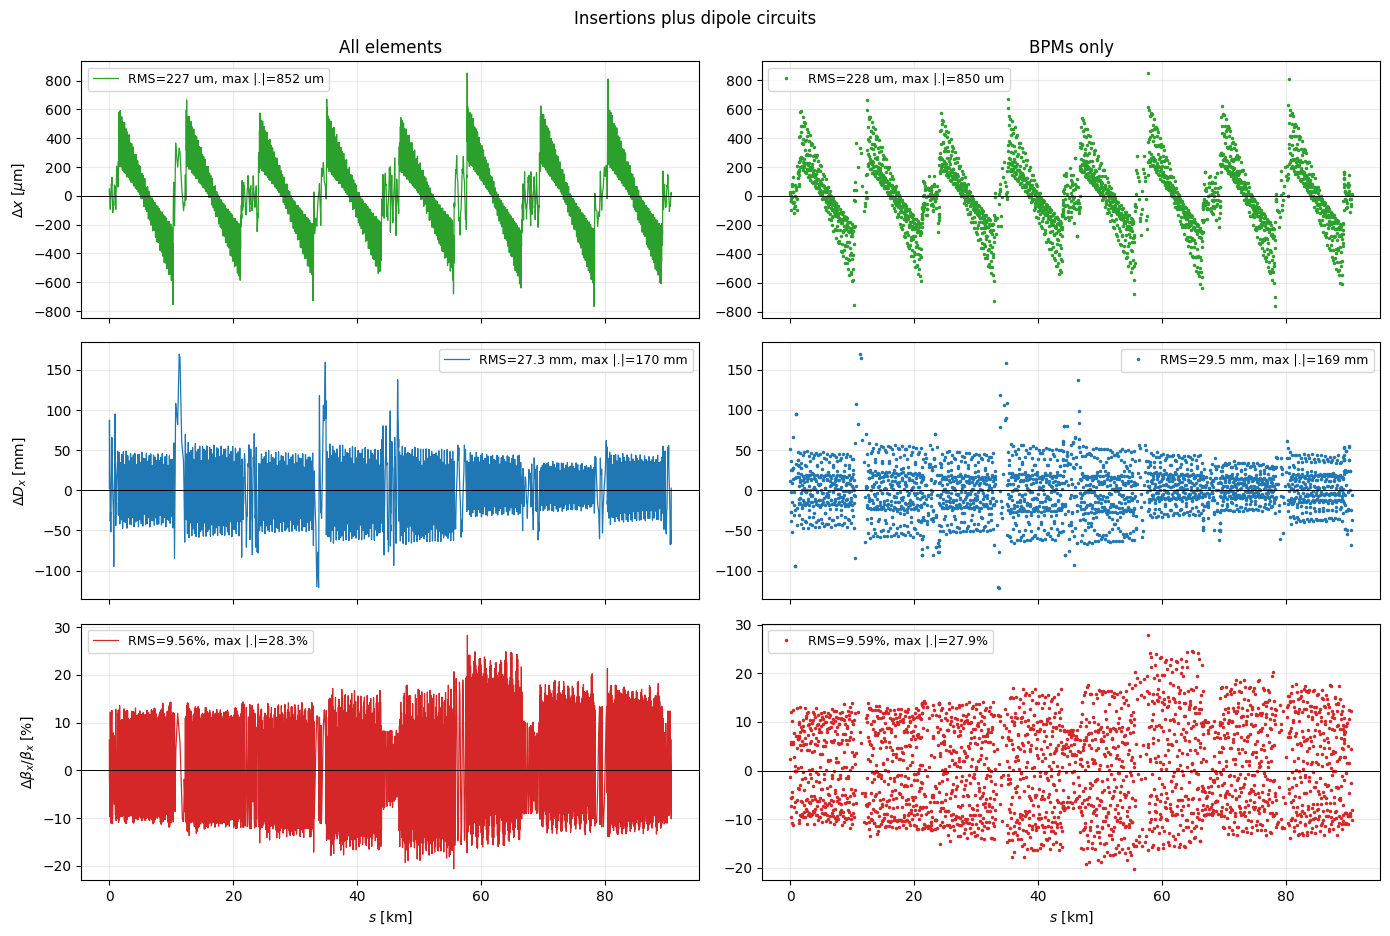

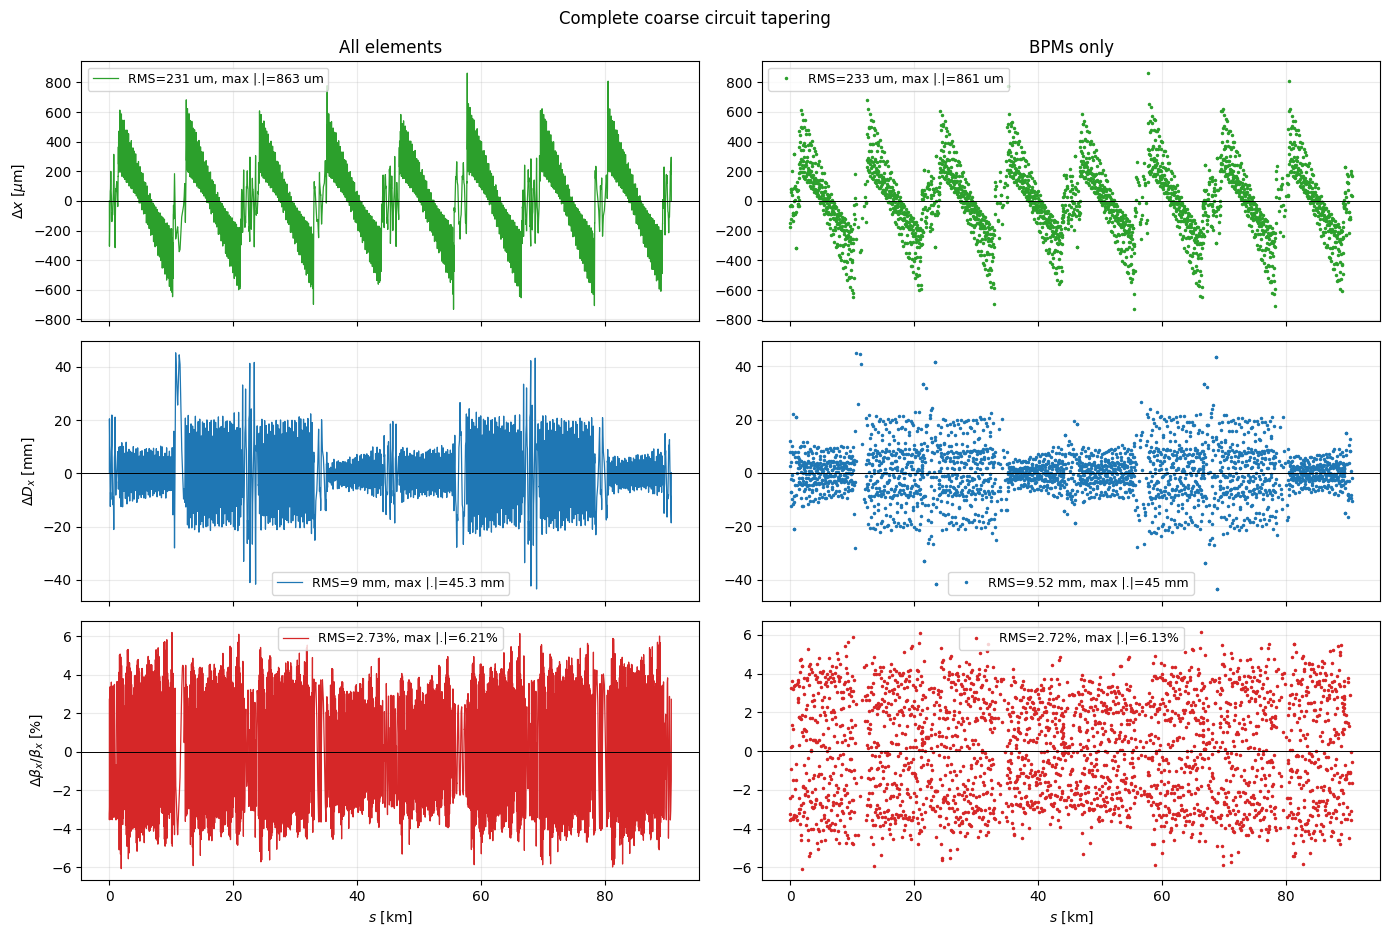

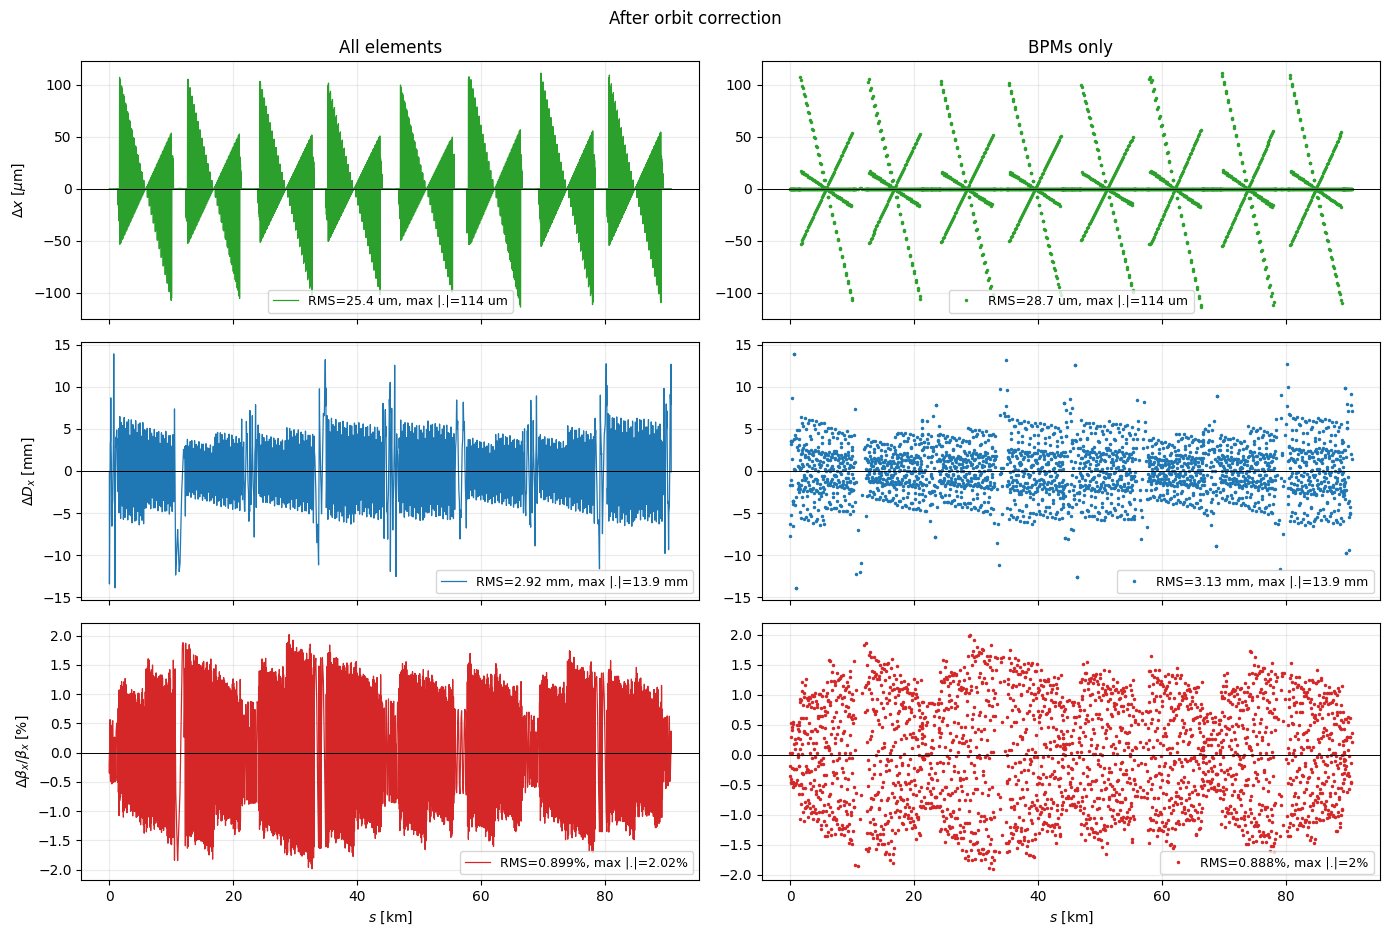

In [39]:
def plot_horizontal_optics_case(twiss_case, reference, label, bpm_names):
    bpm_names = list(np.asarray(bpm_names, dtype=str))

    # All Twiss locations
    s_all_km = np.asarray(reference.s, dtype=float) / 1e3
    delta_orbit_x_all_um = 1e6 * (
        np.asarray(twiss_case.x, dtype=float)
        - np.asarray(reference.x, dtype=float)
    )
    delta_dispersion_all_mm = 1e3 * (
        np.asarray(twiss_case.dx, dtype=float)
        - np.asarray(reference.dx, dtype=float)
    )
    beta_beating_all_percent = 100.0 * (
        np.asarray(twiss_case.betx, dtype=float)
        / np.asarray(reference.betx, dtype=float) - 1.0
    )

    # BPM locations only. Obtain the indices independently from each table.
    reference_bpm_indices = reference.rows.indices[bpm_names]
    case_bpm_indices = twiss_case.rows.indices[bpm_names]
    s_bpm_km = np.asarray(reference.s[reference_bpm_indices], dtype=float) / 1e3
    delta_orbit_x_bpm_um = 1e6 * (
        np.asarray(twiss_case.x[case_bpm_indices], dtype=float)
        - np.asarray(reference.x[reference_bpm_indices], dtype=float)
    )
    delta_dispersion_bpm_mm = 1e3 * (
        np.asarray(twiss_case.dx[case_bpm_indices], dtype=float)
        - np.asarray(reference.dx[reference_bpm_indices], dtype=float)
    )
    beta_beating_bpm_percent = 100.0 * (
        np.asarray(twiss_case.betx[case_bpm_indices], dtype=float)
        / np.asarray(reference.betx[reference_bpm_indices], dtype=float) - 1.0
    )

    def statistics(values):
        values = np.asarray(values, dtype=float)
        return np.sqrt(np.nanmean(values**2)), np.nanmax(np.abs(values))

    orbit_all_rms, orbit_all_max = statistics(delta_orbit_x_all_um)
    orbit_bpm_rms, orbit_bpm_max = statistics(delta_orbit_x_bpm_um)
    dx_all_rms, dx_all_max = statistics(delta_dispersion_all_mm)
    dx_bpm_rms, dx_bpm_max = statistics(delta_dispersion_bpm_mm)
    betx_all_rms, betx_all_max = statistics(beta_beating_all_percent)
    betx_bpm_rms, betx_bpm_max = statistics(beta_beating_bpm_percent)

    fig, axes = plt.subplots(3, 2, figsize=(14, 9.5), sharex='col')
    axes[0, 0].plot(s_all_km, delta_orbit_x_all_um, color='tab:green', lw=0.9,
                    label=f'RMS={orbit_all_rms:.3g} um, max |.|={orbit_all_max:.3g} um')
    axes[0, 1].plot(s_bpm_km, delta_orbit_x_bpm_um, '.', color='tab:green', ms=3,
                    label=f'RMS={orbit_bpm_rms:.3g} um, max |.|={orbit_bpm_max:.3g} um')
    axes[1, 0].plot(s_all_km, delta_dispersion_all_mm, color='tab:blue', lw=0.9,
                    label=f'RMS={dx_all_rms:.3g} mm, max |.|={dx_all_max:.3g} mm')
    axes[1, 1].plot(s_bpm_km, delta_dispersion_bpm_mm, '.', color='tab:blue', ms=3,
                    label=f'RMS={dx_bpm_rms:.3g} mm, max |.|={dx_bpm_max:.3g} mm')
    axes[2, 0].plot(s_all_km, beta_beating_all_percent, color='tab:red', lw=0.9,
                    label=f'RMS={betx_all_rms:.3g}%, max |.|={betx_all_max:.3g}%')
    axes[2, 1].plot(s_bpm_km, beta_beating_bpm_percent, '.', color='tab:red', ms=3,
                    label=f'RMS={betx_bpm_rms:.3g}%, max |.|={betx_bpm_max:.3g}%')

    axes[0, 0].set_title('All elements')
    axes[0, 1].set_title('BPMs only')
    axes[0, 0].set_ylabel(r'$\Delta x$ [$\mu$m]')
    axes[1, 0].set_ylabel(r'$\Delta D_x$ [mm]')
    axes[2, 0].set_ylabel(r'$\Delta\beta_x/\beta_x$ [%]')
    axes[2, 0].set_xlabel(r'$s$ [km]')
    axes[2, 1].set_xlabel(r'$s$ [km]')

    for ax in axes.flat:
        ax.axhline(0.0, color='black', lw=0.7)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

case_twiss_tables = {
    'No magnet tapering': tw_no_taper,
    'Ideal tapering in insertions': twiss_insertion_taper,
    'Insertions plus dipole circuits': twiss_dipole,
    'Complete coarse circuit tapering': twiss_quad_sext,
    'After orbit correction': twiss_after_correction,
}

for case_label, case_twiss in case_twiss_tables.items():
    plot_horizontal_optics_case(case_twiss, twiss_ideal, case_label, monitor_names)

# Orbit-correction convergence and kick distribution

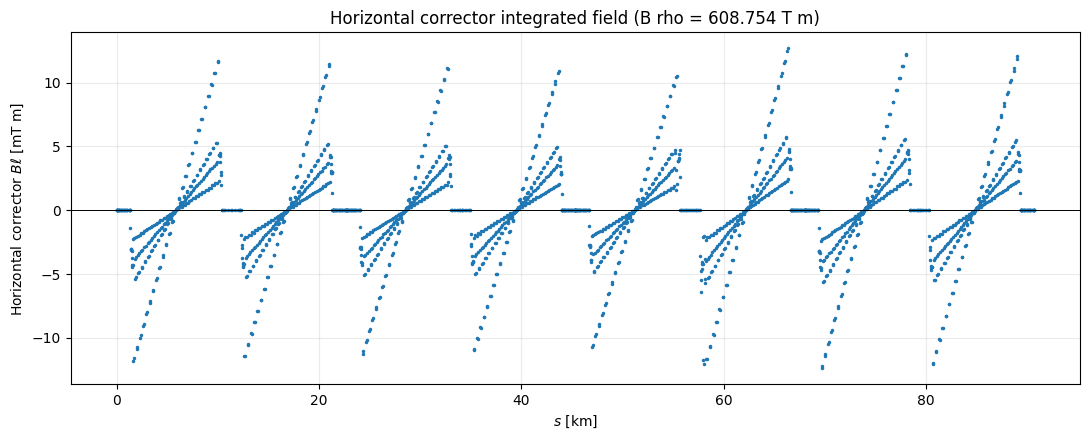

1 urad corresponds to 0.608754 mT m
RMS |B*l| = 3.63185 mT m
Max |B*l| = 12.6926 mT m


In [40]:
# Convert the horizontal angular kicks to equivalent integrated field B*l.
horizontal_kicks_rad = correction.x_correction.get_kick_values()
p0c_GeV = float(line.particle_ref.p0c[0]) * 1e-9
charge_number = abs(float(line.particle_ref.q0))
magnetic_rigidity_Tm = p0c_GeV / (0.299792458 * charge_number)
horizontal_integrated_field_mTm = (horizontal_kicks_rad * magnetic_rigidity_Tm * 1e3) # this will give mT m

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(correction.x_correction.s_correctors / 1e3,
        horizontal_integrated_field_mTm, '.', ms=3)
ax.axhline(0.0, color='black', lw=0.7)
ax.set_xlabel(r'$s$ [km]')
ax.set_ylabel(r'Horizontal corrector $B\ell$ [mT m]')
ax.grid(alpha=0.25)
ax.set_title(
    f'Horizontal corrector integrated field '
    f'(B rho = {magnetic_rigidity_Tm:.3f} T m)'
)
fig.tight_layout()
plt.show()

print(f'1 urad corresponds to {magnetic_rigidity_Tm * 1e-3:.6g} mT m')
print(f'RMS |B*l| = {np.sqrt(np.mean(horizontal_integrated_field_mTm**2)):.6g} mT m')
print(f'Max |B*l| = {np.max(np.abs(horizontal_integrated_field_mTm)):.6g} mT m')

In [41]:
magnetic_rigidity_Tm 

608.7544737342413